libaraies

In [16]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns


# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

load files

In [17]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"


# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")
RI1_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv")
RI2_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv")
RI1_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv")
RI2_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv")
RI1_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv")
RI2_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv")
RI2_3_5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv")


In [18]:
ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

In [19]:
ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [20]:
ri1_boris_data = {
    "RI1_3_6": RI1_3_6_boris.copy(),
    "RI1_4_7": RI1_4_7_boris.copy(),
    "RI1_2_3": RI1_2_3_boris.copy(),
    "RI1_4_8": RI1_4_8_boris.copy(),
    "RI1_1_1": RI1_1_1_boris.copy(),
    "RI1_1_2": RI1_1_2_boris.copy(),
    "RI1_2_4": RI1_2_4_boris.copy(),
}


In [21]:
ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
    "RI2_1_1": RI2_1_1_boris.copy(),
    "RI2_1_2": RI2_1_2_boris.copy(),
    "RI2_2_4": RI2_2_4_boris.copy(),
    "RI2_3_5": RI2_3_5_boris.copy(),
}


load_clean_resp_signal function for loading and preprocessing respiration data:

Reads raw resp signal and metadata from .h5

Computes original sampling rate (fs)

Applies a low-pass filter before downsampling to avoid aliasing

Downsamples the signal to your target_rate (default 100 Hz)

Applies a bandpass filter (0.1–20 Hz) with NeuroKit to clean the signal further

Creates a time vector that matches the cleaned signal length and sampling rate

This function returns:
rsp_cleaned: the cleaned, filtered, downsampled respiratory signal array

time_vector: time points corresponding to each sample in seconds

target_rate: the sampling rate after downsampling (e.g., 100 Hz)

You can then pass these outputs to functions like:
get_percent_change_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_start, sniff_end)

get_delta_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_end)

In [22]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

In [23]:
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [24]:
resp_data = {}

for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("✅ All available signals loaded.")


Processing RI1_3_6...


Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
Processing RI1_1_1...
Processing RI2_1_1...
Processing RI1_1_2...
Processing RI2_1_2...
Processing RI1_2_4...
Processing RI2_2_4...
Processing RI1_3_5...
Processing RI2_3_5...
✅ All available signals loaded.


In [25]:
for subject, df in ri2_boris_data.items():
    count = df[(df['Behavior'] == 'facial sniffing') & (df['Subject'] == 'social_agent')].shape[0]
    print(f"{subject} facial sniffing count: {count}")


RI2_3_6 facial sniffing count: 26
RI2_4_7 facial sniffing count: 21
RI2_2_3 facial sniffing count: 12
RI2_4_8 facial sniffing count: 38
RI2_1_1 facial sniffing count: 4
RI2_1_2 facial sniffing count: 17
RI2_2_4 facial sniffing count: 13
RI2_3_5 facial sniffing count: 6


In [26]:
for subject, df in ri2_boris_data.items():
    count = df[df['Behavior'] == 'fighting'].shape[0]
    print(f"{subject} fight count: {count}")


RI2_3_6 fight count: 18
RI2_4_7 fight count: 30
RI2_2_3 fight count: 14
RI2_4_8 fight count: 28
RI2_1_1 fight count: 8
RI2_1_2 fight count: 3
RI2_2_4 fight count: 13
RI2_3_5 fight count: 8


In [27]:
from scipy.signal import find_peaks

for subject, resp_file in ri2_h5_paths.items():
    resp_signal, resp_times, fs = load_clean_resp_signal(resp_file, target_rate=100)
    if resp_signal is None:
        print(f"{subject}: Resp signal failed to load.")
        continue
    peaks, _ = find_peaks(resp_signal, distance=int(fs * 0.0833))
    print(f"{subject}: {len(peaks)} peaks found in respiration signal.")


RI2_3_6: 3692 peaks found in respiration signal.
RI2_4_7: 4090 peaks found in respiration signal.
RI2_2_3: 4243 peaks found in respiration signal.
RI2_4_8: 3550 peaks found in respiration signal.
RI2_1_1: 3745 peaks found in respiration signal.
RI2_1_2: 4038 peaks found in respiration signal.
RI2_2_4: 3916 peaks found in respiration signal.
RI2_3_5: 1296 peaks found in respiration signal.


In [28]:
for label, path in h5_paths.items():
    print(f"{label} is type {type(path)}")


RI1_3_6 is type <class 'str'>
RI2_3_6 is type <class 'str'>
RI1_4_7 is type <class 'str'>
RI2_4_7 is type <class 'str'>
RI1_2_3 is type <class 'str'>
RI2_2_3 is type <class 'str'>
RI1_4_8 is type <class 'str'>
RI2_4_8 is type <class 'str'>
RI1_1_1 is type <class 'str'>
RI2_1_1 is type <class 'str'>
RI1_1_2 is type <class 'str'>
RI2_1_2 is type <class 'str'>
RI1_2_4 is type <class 'str'>
RI2_2_4 is type <class 'str'>
RI1_3_5 is type <class 'str'>
RI2_3_5 is type <class 'str'>


In [29]:
for key in resp_data:
    print(f"{key}: {len(resp_data[key]['signal'])} samples at {resp_data[key]['sampling_rate']} Hz")


RI1_3_6: 60328 samples at 100 Hz
RI2_3_6: 61001 samples at 100 Hz
RI1_4_7: 62916 samples at 100 Hz
RI2_4_7: 60647 samples at 100 Hz
RI1_2_3: 60295 samples at 100 Hz
RI2_2_3: 60921 samples at 100 Hz
RI1_4_8: 60484 samples at 100 Hz
RI2_4_8: 60324 samples at 100 Hz
RI1_1_1: 62127 samples at 100 Hz
RI2_1_1: 60480 samples at 100 Hz
RI1_1_2: 60448 samples at 100 Hz
RI2_1_2: 60427 samples at 100 Hz
RI1_2_4: 60910 samples at 100 Hz
RI2_2_4: 60545 samples at 100 Hz
RI1_3_5: 62374 samples at 100 Hz
RI2_3_5: 21334 samples at 100 Hz


get_sniff_respiratory_rate function is good for calculating the breathing rate during a sniff bout:

It creates a mask to select the respiratory signal samples between sniff_start and sniff_end.

It uses find_peaks to detect inhalation peaks in that signal segment, with a minimum peak distance of 0.2 seconds (to avoid counting the same breath twice).

It calculates the duration of the sniff bout.

It returns the breathing rate as the number of detected peaks divided by the duration (giving rate in Hz).

A few things to watch out for:
Sampling rate consistency: Make sure the times array and the signal array are aligned and that sampling_rate matches the sampling frequency of the signal.

Peak detection threshold: You might want to tweak the distance or add a height parameter in find_peaks if you get too many or too few peaks.

Edge cases: If duration is zero or very small, it returns np.nan, which is good.



In [30]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate

In [31]:
def extract_agent_face_sniffs(df):
    """
    Filters BORIS dataframe for facial sniffing initiated by the social agent.
    """
    df = df.copy()
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Updated filters
    agent_mask = df['Subject'].str.lower() == 'social_agent'
    sniff_mask = df['Behavior'].str.lower() == 'facial sniffing'

    return df[agent_mask & sniff_mask]


In [32]:
agent_sniffs = extract_agent_face_sniffs(RI2_3_6_boris)
print(agent_sniffs[['Subject', 'Behavior', 'Start (s)', 'Stop (s)']])


          Subject         Behavior  Start (s)  Stop (s)
12   social_agent  facial sniffing     25.600    26.100
23   social_agent  facial sniffing     68.767    69.600
36   social_agent  facial sniffing     91.900    92.267
40   social_agent  facial sniffing    153.900   154.400
41   social_agent  facial sniffing    156.233   156.567
43   social_agent  facial sniffing    195.433   195.767
46   social_agent  facial sniffing    196.167   197.500
53   social_agent  facial sniffing    218.300   219.367
59   social_agent  facial sniffing    226.433   226.900
64   social_agent  facial sniffing    234.867   235.367
67   social_agent  facial sniffing    249.733   250.567
68   social_agent  facial sniffing    257.833   258.367
70   social_agent  facial sniffing    267.400   268.933
71   social_agent  facial sniffing    269.767   270.600
75   social_agent  facial sniffing    273.367   274.200
78   social_agent  facial sniffing    282.033   283.067
79   social_agent  facial sniffing    288.200   

In [33]:
agent_sniffs

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
12,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,25.600,26.100,0.500,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,768,783.0,NaN,NaN,NaN,NaN
23,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,68.767,69.600,0.833,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,2063,2088.0,NaN,NaN,NaN,NaN
36,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,91.900,92.267,0.367,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,2757,2768.0,NaN,NaN,NaN,NaN
40,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,153.900,154.400,0.500,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,4617,4632.0,NaN,NaN,NaN,NaN
41,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,156.233,156.567,0.334,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,4687,4697.0,NaN,NaN,NaN,NaN
43,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,195.433,195.767,0.334,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,5863,5873.0,NaN,NaN,NaN,NaN
46,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,196.167,197.500,1.333,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,5885,5925.0,NaN,NaN,NaN,NaN
53,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,218.300,219.367,1.067,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,6549,6581.0,NaN,NaN,NaN,NaN
59,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,226.433,226.900,0.467,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_2

In [34]:
all_agent_sniffs = []

# Loop through each trial in RI2
for label, boris_df in ri2_boris_data.items():
    agent_sniffs = extract_agent_face_sniffs(boris_df)
    agent_sniffs["Trial"] = label  # Add which trial/mouse it came from
    all_agent_sniffs.append(agent_sniffs)

# Combine all the individual DataFrames into one
combined_sniffs_df = pd.concat(all_agent_sniffs, ignore_index=True)

# Preview the result
print(combined_sniffs_df[['Trial', 'Subject', 'Behavior', 'Start (s)', 'Stop (s)']].head())


     Trial       Subject         Behavior  Start (s)  Stop (s)
0  RI2_3_6  social_agent  facial sniffing     25.600    26.100
1  RI2_3_6  social_agent  facial sniffing     68.767    69.600
2  RI2_3_6  social_agent  facial sniffing     91.900    92.267
3  RI2_3_6  social_agent  facial sniffing    153.900   154.400
4  RI2_3_6  social_agent  facial sniffing    156.233   156.567


In [35]:
combined_sniffs_df

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop,Trial,Media file,Total length,FPS,Modifiers
0,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.900,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,25.600,26.100,0.500,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,768.0,783.0,NaN,NaN,NaN,NaN,RI2_3_6,NaN,NaN,NaN,NaN
1,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.900,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,68.767,69.600,0.833,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,2063.0,2088.0,NaN,NaN,NaN,NaN,RI2_3_6,NaN,NaN,NaN,NaN
2,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.900,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,91.900,92.267,0.367,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,2757.0,2768.0,NaN,NaN,NaN,NaN,RI2_3_6,NaN,NaN,NaN,NaN
3,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.900,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,153.900,154.400,0.500,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,4617.0,4632.0,NaN,NaN,NaN,NaN,RI2_3_6,NaN,NaN,NaN,NaN
4,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.900,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,156.233,156.567,0.334,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,4687.0,4697.0,NaN,NaN,NaN,NaN,RI2_3_6,NaN,NaN,NaN,NaN
5,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.900,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,195.433,195.767,0.334,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,5863.0,5873.0,NaN,NaN,NaN,NaN,RI2_3_6,NaN,NaN,NaN,NaN
6,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.900,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,196.167,197.500,1.333,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,5885.0,5925.0,NaN,NaN,NaN,NaN,RI2_3_6,NaN,NaN,NaN,NaN
7,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.900,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,218.300,219.367,1.067,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,6549.0,6581.0,NaN,NaN,NaN,NaN,RI2_3_6,NaN,NaN,NaN,NaN
8,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3

In [36]:
def calculate_percent_change_ibi(signal, time, sniff_start, sampling_rate=100):
    """
    Calculates % change in IBI using:
    - Baseline: -1.5s to -0.5s before sniff
    - Post-sniff: +0.5s to +1.5s after sniff

    Returns:
        float: % change in IBI, or None if not enough peaks
    """
    # Define time windows
    baseline_mask = (time >= sniff_start - 1.5) & (time < sniff_start - 0.5)
    post_mask = (time >= sniff_start + 0.5) & (time < sniff_start + 1.5)

    baseline_segment = signal[baseline_mask]
    post_segment = signal[post_mask]

    min_distance = int(0.2 * sampling_rate)  # at least 200 ms between peaks

    baseline_peaks, _ = find_peaks(baseline_segment, distance=min_distance)
    post_peaks, _ = find_peaks(post_segment, distance=min_distance)

    baseline_peak_times = time[baseline_mask][baseline_peaks]
    post_peak_times = time[post_mask][post_peaks]

    # Calculate IBIs
    baseline_ibis = np.diff(baseline_peak_times)
    post_ibis = np.diff(post_peak_times)

    if len(baseline_ibis) == 0 or len(post_ibis) == 0:
        return None

    baseline_mean_ibi = np.mean(baseline_ibis)
    post_mean_ibi = np.mean(post_ibis)

    percent_change = ((post_mean_ibi - baseline_mean_ibi) / baseline_mean_ibi) * 100
    return percent_change


In [37]:
sniff_start = agent_sniffs.iloc[0]["Start (s)"]
signal = resp_data["RI2_3_6"]["signal"]
time = resp_data["RI2_3_6"]["time"]
sr = resp_data["RI2_3_6"]["sampling_rate"]

calculate_percent_change_ibi(signal, time, sniff_start, sr)


9.090909090909086

baseline_mask = (time >= sniff_start - 1.5) & (time < sniff_start - 0.5)
post_mask     = (time >= sniff_start + 0.5) & (time < sniff_start + 1.5)

🟢 These define time windows:

Baseline window = from 1.5s before to 0.5s before the sniff

Post-sniff window = from 0.5s after to 1.5s after the sniff

So we ignore the sniff itself (−0.5 to +0.5), and only look at clean periods before and after.

baseline_peaks, _ = find_peaks(signal[baseline_mask], distance=0.2 * sampling_rate)
post_peaks, _     = find_peaks(signal[post_mask], distance=0.2 * sampling_rate)

🟢 This finds breath peaks in the respiration signal during each window:

find_peaks(...) detects upward spikes (inhalations or cycle peaks)

distance=0.2 * sampling_rate means it skips peaks closer than 200 ms apart ask Dan and Nancy about this threshold. 

baseline_times = time[baseline_mask][baseline_peaks]
post_times     = time[post_mask][post_peaks]

🟢 This gives you the actual time values of those breath peaks (in seconds).

So you now have the times of each breath in each window.

baseline_ibis = np.diff(baseline_times)
post_ibis     = np.diff(post_times)

🟢 This calculates the inter-breath intervals (IBIs):

np.diff(...) gives the time between consecutive breaths

if len(baseline_ibis) == 0 or len(post_ibis) == 0:
    return None

🛑 Safety check — if no IBIs found in either window (e.g. too few breaths), skip it.

baseline_rate = 1 / np.mean(baseline_ibis)
post_rate     = 1 / np.mean(post_ibis)

✅ This converts IBI to breathing rate (Hz):

Rate = 1 / mean IBI

Units = breaths per second

baseline_rate = 1 / np.mean(baseline_ibis)
post_rate     = 1 / np.mean(post_ibis)

✅ This converts IBI to breathing rate (Hz):

Rate = 1 / mean IBI

Units = breaths per second

rate_change = (post_rate - baseline_rate) / baseline_rate * 100

🧮 This computes % change in breathing rate:

Positive = breathing sped up

Negative = breathing slowed down

🔁 Summary of Logic:

Get time windows before and after sniff

Find breaths in each window

Calculate IBI → convert to rate

Compare post vs. baseline rate

Return % change

In [38]:
def percent_change_resp_rate(signal, time, sniff_start, sampling_rate=100):
    baseline_mask = (time >= sniff_start - 1.5) & (time < sniff_start - 0.5)
    post_mask = (time >= sniff_start + 0.5) & (time < sniff_start + 1.5)

    baseline_peaks, _ = find_peaks(signal[baseline_mask], distance=0.2 * sampling_rate)
    post_peaks, _ = find_peaks(signal[post_mask], distance=0.2 * sampling_rate)

    baseline_times = time[baseline_mask][baseline_peaks]
    post_times = time[post_mask][post_peaks]

    baseline_ibis = np.diff(baseline_times)
    post_ibis = np.diff(post_times)

    if len(baseline_ibis) == 0 or len(post_ibis) == 0:
        return None

    baseline_rate = 1 / np.mean(baseline_ibis)
    post_rate = 1 / np.mean(post_ibis)

    rate_change = (post_rate - baseline_rate) / baseline_rate * 100
    return rate_change


In [39]:
sniff_start = agent_sniffs.iloc[0]["Start (s)"]
signal = resp_data["RI2_3_6"]["signal"]
time = resp_data["RI2_3_6"]["time"]
sr = resp_data["RI2_3_6"]["sampling_rate"]

ibi_pct = calculate_percent_change_ibi(signal, time, sniff_start, sr)
rate_pct = percent_change_resp_rate(signal, time, sniff_start, sr)

print(f"% Change in IBI:   {ibi_pct:.2f}%")
print(f"% Change in Rate: {-ibi_pct:.2f}%  <-- inverted")
print(f"% Change in Rate (from rate): {rate_pct:.2f}%")


% Change in IBI:   9.09%
% Change in Rate: -9.09%  <-- inverted
% Change in Rate (from rate): -8.33%


In [40]:
def extract_agent_face_sniffs(df):
    """
    Filters BORIS dataframe for 'Face Sniff' behaviors initiated by the social agent.
    Assumes 'Behavior' and 'Subject' columns exist.
    """
    df = df.copy()
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)
    df = df.sort_values(by='Start (s)').reset_index(drop=True)
    
    # Adjust these string filters to match your BORIS labels
    mask = (df['Behavior'].str.contains("Face Sniff", case=False)) & \
           (df['Subject'].str.lower().str.contains("agent"))
    return df[mask]


In [41]:
def extract_agent_sniff_events(df):
    """
    Filter BORIS DataFrame for agent-initiated sniffing events (face, body, anogenital).
    """
    sniff_behaviors = ["facial sniffing", "body sniffing", "anogenital sniffing"]
    
    # Ensure consistent capitalization (BORIS might use different cases)
    df["Behavior"] = df["Behavior"].str.lower()
    df["Subject"] = df["Subject"].str.lower()

    agent_sniffs = df[
        (df["Subject"] == "social_agent") &
        (df["Behavior"].isin(sniff_behaviors))
    ].copy()

    return agent_sniffs.reset_index(drop=True)


In [42]:
def extract_agent_behavior_events(df, behaviors_to_extract):
    """
    Extracts social agent-initiated events from BORIS dataframe for specified behaviors.
    
    Parameters:
        df (pd.DataFrame): BORIS dataframe
        behaviors_to_extract (list of str): List of behaviors to filter (e.g., ["fighting"])
        
    Returns:
        pd.DataFrame: Filtered BORIS events for those behaviors
    """
    return df[
        (df["Subject"].str.lower() == "social_agent") &
        (df["Behavior"].str.lower().isin([b.lower() for b in behaviors_to_extract]))
    ].copy()


In [43]:
# Select the dataframe
df = RI2_3_6_boris

# Specify the behavior(s) you want to extract
behaviors = ["fighting"]

# Extract the agent-initiated fighting events
agent_fighting = extract_agent_behavior_events(df, behaviors)

# Preview results
print(agent_fighting[["Subject", "Behavior", "Start (s)", "Stop (s)"]])


          Subject  Behavior  Start (s)  Stop (s)
25   social_agent  fighting     70.833    80.533
27   social_agent  fighting     80.900    81.567
30   social_agent  fighting     83.167    83.332
49   social_agent  fighting    201.867   207.033
51   social_agent  fighting    207.767   211.333
55   social_agent  fighting    220.233   222.900
57   social_agent  fighting    224.300   225.833
60   social_agent  fighting    227.033   228.267
73   social_agent  fighting    272.100   272.833
76   social_agent  fighting    274.200   281.400
83   social_agent  fighting    351.333   371.167
85   social_agent  fighting    376.367   384.867
87   social_agent  fighting    391.700   396.167
92   social_agent  fighting    456.133   456.567
94   social_agent  fighting    457.300   464.800
96   social_agent  fighting    465.767   470.233
103  social_agent  fighting    552.067   553.267
108  social_agent  fighting    598.200   608.733


In [44]:
fighting_results = []

for label, df in ri2_boris_data.items():
    resp_entry = resp_data.get(label)
    if resp_entry is None:
        print(f"Skipping {label}: no respiration data.")
        continue

    # Extract agent-initiated fighting events
    events = extract_agent_behavior_events(df, ["fighting"])
    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sr = resp_entry["sampling_rate"]

    for _, row in events.iterrows():
        sniff_start = row["Start (s)"]
        rate_change = percent_change_resp_rate(signal, time, sniff_start, sr)
        if rate_change is None:
            continue
        fighting_results.append({
            "Trial": label,
            "Condition": "RI2",
            "Behavior": "fighting",
            "Sniff Time (s)": sniff_start,
            "% Change Rate": rate_change
        })

# Combine results into DataFrame
ri2_fighting_df = pd.DataFrame(fighting_results)
print(ri2_fighting_df.head())


     Trial Condition  Behavior  Sniff Time (s)  % Change Rate
0  RI2_3_6       RI2  fighting          70.833      -9.638554
1  RI2_3_6       RI2  fighting          80.900       7.692308
2  RI2_3_6       RI2  fighting          83.167       2.469136
3  RI2_3_6       RI2  fighting         201.867     -31.007752
4  RI2_3_6       RI2  fighting         207.767     -10.465116


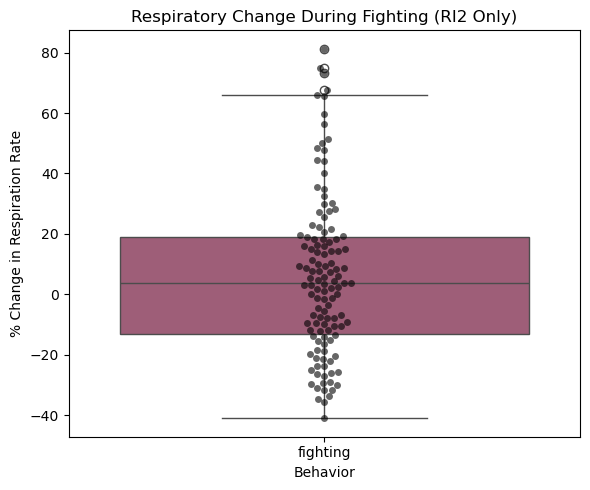

In [45]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=ri2_fighting_df,
    x='Behavior',
    y='% Change Rate',
    color=(169/255,83/255,118/255)  # RI2 color
)
sns.swarmplot(
    data=ri2_fighting_df,
    x='Behavior',
    y='% Change Rate',
    color='k',
    alpha=0.6
)
plt.title("Respiratory Change During Fighting (RI2 Only)")
plt.ylabel("% Change in Respiration Rate")
plt.tight_layout()
plt.show()


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

sns.stripplot(
    data=combined_df,
    x='Behavior',
    y='% Change Rate',
    hue='Trial',       # This will show different mice (trials)
    jitter=True,
    dodge=True,
    marker='o',
    alpha=0.6
)

plt.title('Mouse-Level % Resp Change by Behavior')
plt.xticks(rotation=30)
plt.axhline(0, color='gray', linestyle='--')  # horizontal line at 0 change
plt.legend(bbox_to_anchor=(1,1), title="Mouse")
plt.tight_layout()
plt.show()


NameError: name 'combined_df' is not defined

<Figure size 1400x600 with 0 Axes>

In [47]:
agent_events = extract_agent_sniff_events(RI2_3_6_boris)
print(agent_events[["Behavior", "Start (s)"]])



               Behavior  Start (s)
0       facial sniffing     25.600
1         body sniffing     26.167
2   anogenital sniffing     26.600
3       facial sniffing     68.767
4       facial sniffing     91.900
5       facial sniffing    153.900
6       facial sniffing    156.233
7       facial sniffing    195.433
8         body sniffing    195.767
9       facial sniffing    196.167
10        body sniffing    198.333
11      facial sniffing    218.300
12        body sniffing    219.433
13      facial sniffing    226.433
14        body sniffing    228.433
15  anogenital sniffing    234.167
16      facial sniffing    234.867
17  anogenital sniffing    235.567
18      facial sniffing    249.733
19      facial sniffing    257.833
20      facial sniffing    267.400
21      facial sniffing    269.767
22      facial sniffing    273.367
23      facial sniffing    282.033
24      facial sniffing    288.200
25      facial sniffing    290.133
26      facial sniffing    318.700
27      facial sniff

In [48]:
# Store results in a list
results = []

# Get respiration info for this trial
resp_entry = resp_data["RI2_3_6"]
signal = resp_entry["signal"]
time = resp_entry["time"]
sr = resp_entry["sampling_rate"]

# Loop through all agent sniff events
for idx, row in agent_events.iterrows():
    behavior = row["Behavior"]
    sniff_start = row["Start (s)"]

    # Calculate % change in rate using your function
    rate_change = percent_change_resp_rate(signal, time, sniff_start, sr)

    # Skip if calculation failed (e.g., not enough breaths)
    if rate_change is None:
        continue

    # Store result
    results.append({
        "Trial": "RI2_3_6",
        "Behavior": behavior,
        "Sniff Time (s)": sniff_start,
        "% Change Rate": rate_change
    })


In [49]:
rate_df = pd.DataFrame(results)
print(rate_df)


      Trial             Behavior  Sniff Time (s)  % Change Rate
0   RI2_3_6      facial sniffing          25.600  -1.182432e+01
1   RI2_3_6        body sniffing          26.167  -7.602339e+00
2   RI2_3_6  anogenital sniffing          26.600   6.578947e+00
3   RI2_3_6      facial sniffing          68.767  -4.000000e+00
4   RI2_3_6      facial sniffing          91.900   2.740741e+01
5   RI2_3_6      facial sniffing         153.900   3.000000e+01
6   RI2_3_6      facial sniffing         156.233  -2.840909e+01
7   RI2_3_6      facial sniffing         195.433  -2.266667e+01
8   RI2_3_6        body sniffing         195.767  -1.919192e+01
9   RI2_3_6      facial sniffing         196.167   0.000000e+00
10  RI2_3_6        body sniffing         198.333  -1.534392e+01
11  RI2_3_6      facial sniffing         218.300   1.612903e+00
12  RI2_3_6        body sniffing         219.433  -2.394366e+01
13  RI2_3_6      facial sniffing         226.433  -3.493976e+01
14  RI2_3_6        body sniffing        

In [50]:
ri2_results = []

# Loop through all RI2 trials dynamically
for label, boris_df in ri2_boris_data.items():
    resp_entry = resp_data.get(label)

    if resp_entry is None:
        print(f"Skipping {label}: no respiration data.")
        continue

    agent_events = extract_agent_sniff_events(boris_df)
    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sr = resp_entry["sampling_rate"]

    for _, row in agent_events.iterrows():
        behavior = row["Behavior"]
        sniff_start = row["Start (s)"]

        rate_change = percent_change_resp_rate(signal, time, sniff_start, sr)
        if rate_change is None:
            continue

        ri2_results.append({
            "Trial": label,
            "Condition": "RI2",
            "Behavior": behavior,
            "Sniff Time (s)": sniff_start,
            "% Change Rate": rate_change
        })

# Convert to DataFrame
ri2_df = pd.DataFrame(ri2_results)
print(ri2_df.head())


     Trial Condition             Behavior  Sniff Time (s)  % Change Rate
0  RI2_3_6       RI2      facial sniffing          25.600     -11.824324
1  RI2_3_6       RI2        body sniffing          26.167      -7.602339
2  RI2_3_6       RI2  anogenital sniffing          26.600       6.578947
3  RI2_3_6       RI2      facial sniffing          68.767      -4.000000
4  RI2_3_6       RI2      facial sniffing          91.900      27.407407


In [51]:
ri2_df

,Trial,Condition,Behavior,Sniff Time (s),% Change Rate
0,RI2_3_6,RI2,facial sniffing,25.600,-1.182432e+01
1,RI2_3_6,RI2,body sniffing,26.167,-7.602339e+00
2,RI2_3_6,RI2,anogenital sniffing,26.600,6.578947e+00
3,RI2_3_6,RI2,facial sniffing,68.767,-4.000000e+00
4,RI2_3_6,RI2,facial sniffing,91.900,2.740741e+01
5,RI2_3_6,RI2,facial sniffing,153.900,3.000000e+01
6,RI2_3_6,RI2,facial sniffing,156.233,-2.840909e+01
7,RI2_3_6,RI2,facial sniffing,195.433,-2.266667e+01
8,RI2_3_6,RI2,body sniffing,195.767,-1.919192e+01
9,RI2_3_6,RI2,facial sniffing,196.167,0.000000e+00


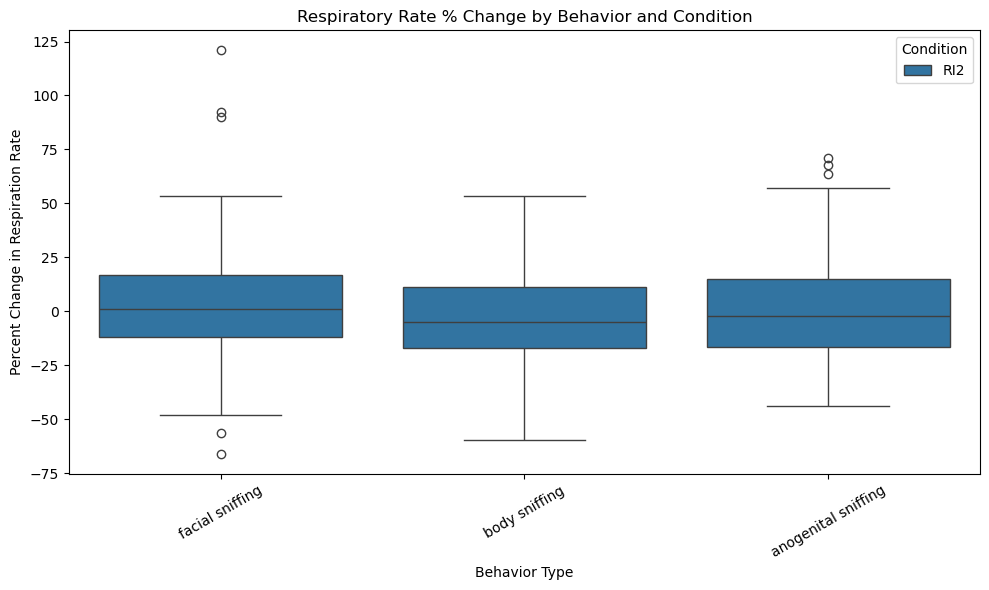

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(
    data=ri2_df, 
    x='Behavior', 
    y='% Change Rate', 
    hue='Condition'
)
plt.title('Respiratory Rate % Change by Behavior and Condition')
plt.xticks(rotation=30)
plt.ylabel('Percent Change in Respiration Rate')
plt.xlabel('Behavior Type')
plt.tight_layout()
plt.show()


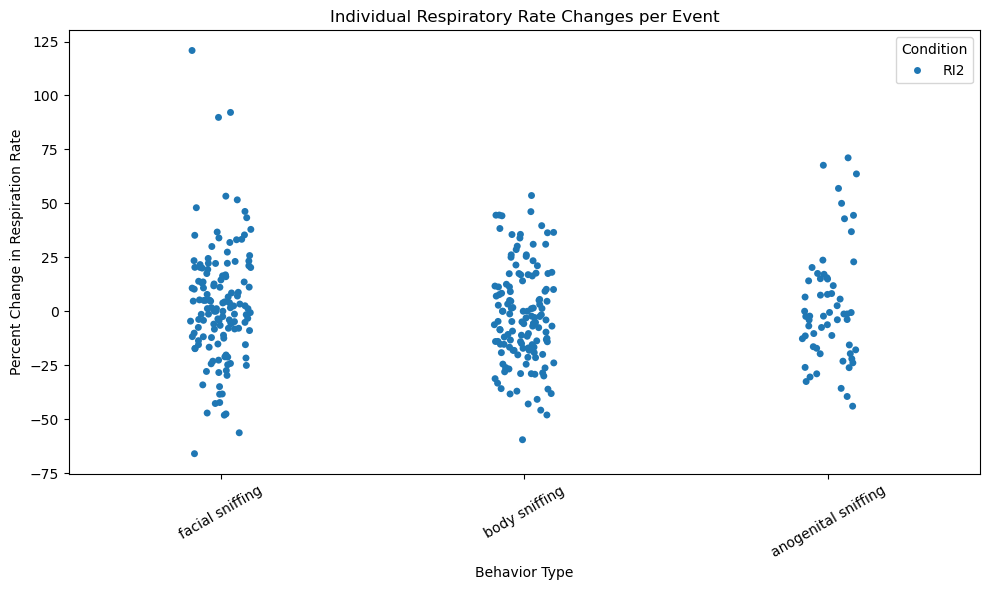

In [53]:
plt.figure(figsize=(10,6))
sns.stripplot(
    data=ri2_df,
    x='Behavior',
    y='% Change Rate',
    hue='Condition',
    jitter=True,
    dodge=True
)
plt.title('Individual Respiratory Rate Changes per Event')
plt.xticks(rotation=30)
plt.ylabel('Percent Change in Respiration Rate')
plt.xlabel('Behavior Type')
plt.tight_layout()
plt.show()


In [54]:
ri1_results = []

for label in ["RI1_3_6", "RI1_4_7", "RI1_2_3", "RI1_4_8"]:
    boris_df = globals()[label + "_boris"]  # grab the BORIS dataframe by variable name
    resp_entry = resp_data.get(label)

    if resp_entry is None:
        print(f"Skipping {label}: no respiration data.")
        continue

    agent_events = extract_agent_sniff_events(boris_df)
    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sr = resp_entry["sampling_rate"]

    for _, row in agent_events.iterrows():
        behavior = row["Behavior"]
        sniff_start = row["Start (s)"]

        rate_change = percent_change_resp_rate(signal, time, sniff_start, sr)
        if rate_change is None:
            continue

        ri1_results.append({
            "Trial": label,
            "Condition": "RI1",
            "Behavior": behavior,
            "Sniff Time (s)": sniff_start,
            "% Change Rate": rate_change
        })

ri1_df = pd.DataFrame(ri1_results)
print(ri1_df.head())


     Trial Condition             Behavior  Sniff Time (s)  % Change Rate
0  RI1_3_6       RI1  anogenital sniffing           8.862     -15.789474
1  RI1_3_6       RI1      facial sniffing          12.069       0.000000
2  RI1_3_6       RI1  anogenital sniffing          80.310      -8.474576
3  RI1_3_6       RI1      facial sniffing          86.207       1.388889
4  RI1_3_6       RI1      facial sniffing          88.034     -16.666667


In [55]:
ri1_df

,Trial,Condition,Behavior,Sniff Time (s),% Change Rate
0,RI1_3_6,RI1,anogenital sniffing,8.862,-1.578947e+01
1,RI1_3_6,RI1,facial sniffing,12.069,0.000000e+00
2,RI1_3_6,RI1,anogenital sniffing,80.310,-8.474576e+00
3,RI1_3_6,RI1,facial sniffing,86.207,1.388889e+00
4,RI1_3_6,RI1,facial sniffing,88.034,-1.666667e+01
5,RI1_3_6,RI1,anogenital sniffing,90.690,-2.156863e+01
6,RI1_3_6,RI1,facial sniffing,107.724,-3.059361e+01
7,RI1_3_6,RI1,facial sniffing,183.724,-1.250000e+01
8,RI1_3_6,RI1,facial sniffing,200.517,4.805195e+01
9,RI1_3_6,RI1,facial sniffing,217.172,1.733333e+01


In [56]:
combined_df = pd.concat([ri1_df, ri2_df], ignore_index=True)
print(combined_df.head())


     Trial Condition             Behavior  Sniff Time (s)  % Change Rate
0  RI1_3_6       RI1  anogenital sniffing           8.862     -15.789474
1  RI1_3_6       RI1      facial sniffing          12.069       0.000000
2  RI1_3_6       RI1  anogenital sniffing          80.310      -8.474576
3  RI1_3_6       RI1      facial sniffing          86.207       1.388889
4  RI1_3_6       RI1      facial sniffing          88.034     -16.666667


In [57]:
combined_df

,Trial,Condition,Behavior,Sniff Time (s),% Change Rate
0,RI1_3_6,RI1,anogenital sniffing,8.862,-1.578947e+01
1,RI1_3_6,RI1,facial sniffing,12.069,0.000000e+00
2,RI1_3_6,RI1,anogenital sniffing,80.310,-8.474576e+00
3,RI1_3_6,RI1,facial sniffing,86.207,1.388889e+00
4,RI1_3_6,RI1,facial sniffing,88.034,-1.666667e+01
5,RI1_3_6,RI1,anogenital sniffing,90.690,-2.156863e+01
6,RI1_3_6,RI1,facial sniffing,107.724,-3.059361e+01
7,RI1_3_6,RI1,facial sniffing,183.724,-1.250000e+01
8,RI1_3_6,RI1,facial sniffing,200.517,4.805195e+01
9,RI1_3_6,RI1,facial sniffing,217.172,1.733333e+01


In [58]:
combined_df['Condition Label'] = combined_df['Condition'].map({
    'RI1': 'Positive Social Interaction',
    'RI2': 'Negative Social Interaction'
})


In [59]:
colors = {
    'Positive Social Interaction': (83/255, 161/255, 169/255),  # teal-ish
    'Negative Social Interaction': (169/255, 83/255, 118/255)   # purplish
}


In [60]:
colors = {
    'Positive Social Interaction': (83/255, 161/255, 169/255),  # teal-ish
    'Negative Social Interaction': (169/255, 83/255, 118/255)   # purplish
}


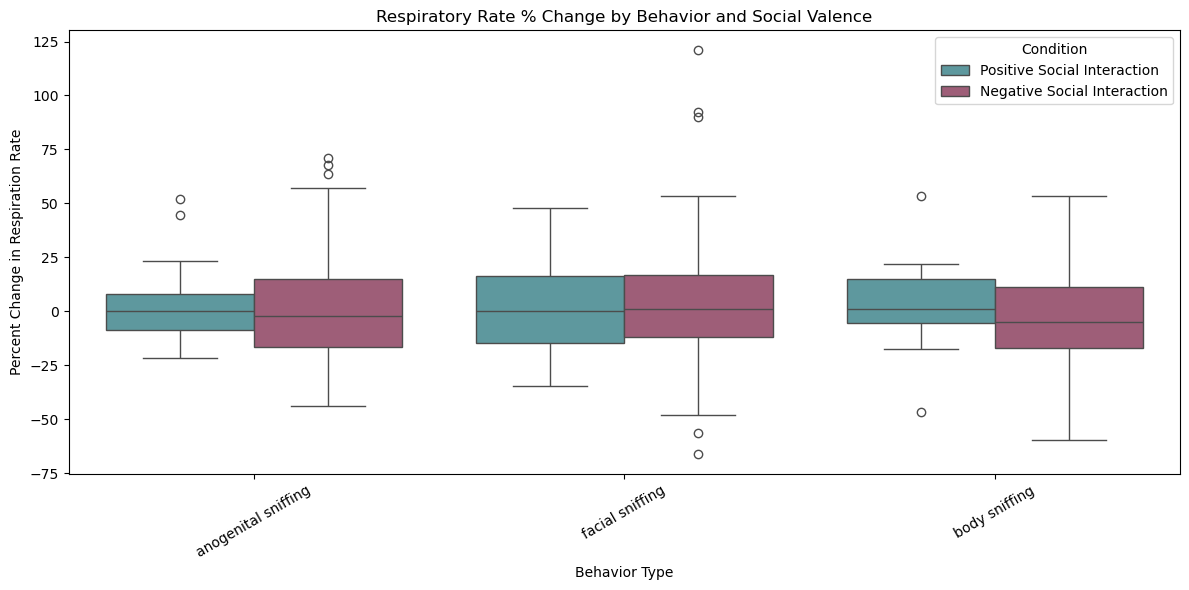

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(
    data=combined_df,
    x='Behavior',
    y='% Change Rate',
    hue='Condition Label',
    palette=colors
)
plt.title('Respiratory Rate % Change by Behavior and Social Valence')
plt.xticks(rotation=30)
plt.ylabel('Percent Change in Respiration Rate')
plt.xlabel('Behavior Type')
plt.legend(title='Condition')
plt.tight_layout()
plt.show()


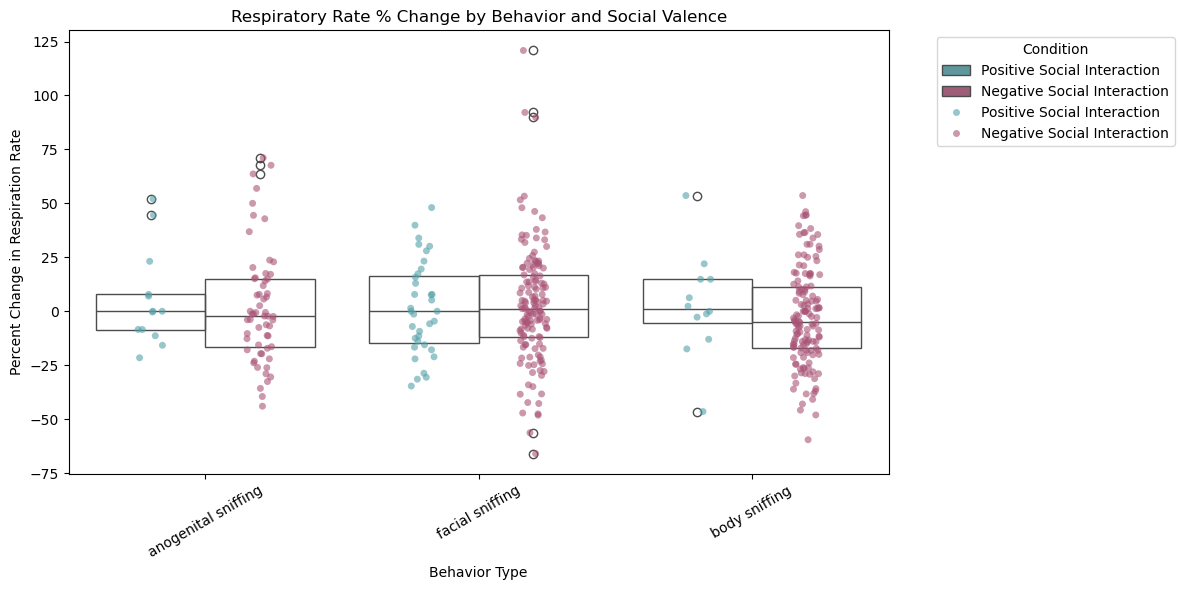

In [62]:
plt.figure(figsize=(12,6))

# Boxplot (summary)
sns.boxplot(
    data=combined_df,
    x='Behavior',
    y='% Change Rate',
    hue='Condition Label',
    palette=colors,
    showcaps=False,
    boxprops={'facecolor':'None'},
    whiskerprops={'linewidth':0}
)

# Stripplot (individual points)
sns.stripplot(
    data=combined_df,
    x='Behavior',
    y='% Change Rate',
    hue='Condition Label',
    dodge=True,
    palette=colors,
    alpha=0.6,
    jitter=True,
    marker='o'
)

plt.title('Respiratory Rate % Change by Behavior and Social Valence')
plt.xticks(rotation=30)
plt.ylabel('Percent Change in Respiration Rate')
plt.xlabel('Behavior Type')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [63]:
combined_df

,Trial,Condition,Behavior,Sniff Time (s),% Change Rate,Condition Label
0,RI1_3_6,RI1,anogenital sniffing,8.862,-1.578947e+01,Positive Social Interaction
1,RI1_3_6,RI1,facial sniffing,12.069,0.000000e+00,Positive Social Interaction
2,RI1_3_6,RI1,anogenital sniffing,80.310,-8.474576e+00,Positive Social Interaction
3,RI1_3_6,RI1,facial sniffing,86.207,1.388889e+00,Positive Social Interaction
4,RI1_3_6,RI1,facial sniffing,88.034,-1.666667e+01,Positive Social Interaction
5,RI1_3_6,RI1,anogenital sniffing,90.690,-2.156863e+01,Positive Social Interaction
6,RI1_3_6,RI1,facial sniffing,107.724,-3.059361e+01,Positive Social Interaction
7,RI1_3_6,RI1,facial sniffing,183.724,-1.250000e+01,Positive Social Interaction
8,RI1_3_6,RI1,facial sniffing,200.517,4.805195e+01,Positive Social Interaction
9,RI1_3_6,RI1,facial sniffing,217.172,1.733333e+01,Positive Social Interaction


In [64]:
from scipy.stats import ttest_ind

behaviors = combined_df['Behavior'].unique()

for behavior in behaviors:
    pos_vals = combined_df.loc[
        (combined_df['Behavior'] == behavior) & 
        (combined_df['Condition'] == 'RI1'), '% Change Rate'
    ].dropna()
    neg_vals = combined_df.loc[
        (combined_df['Behavior'] == behavior) & 
        (combined_df['Condition'] == 'RI2'), '% Change Rate'
    ].dropna()
    
    if len(pos_vals) > 1 and len(neg_vals) > 1:
        stat, pval = ttest_ind(pos_vals, neg_vals, equal_var=False)
        print(f"Behavior: {behavior:20} | p-value = {pval:.4f}")
    else:
        print(f"Behavior: {behavior:20} | Not enough data for test")


Behavior: anogenital sniffing  | p-value = 0.6474
Behavior: facial sniffing      | p-value = 0.7278
Behavior: body sniffing        | p-value = 0.4785


In [65]:
def percent_change_resp_rate(signal, time, sniff_start, sampling_rate=100,
                             baseline_start_offset=-1.5, baseline_end_offset=-0.5,
                             post_start_offset=0.5, post_end_offset=1.5):
    baseline_mask = (time >= sniff_start + baseline_start_offset) & (time < sniff_start + baseline_end_offset)
    post_mask = (time >= sniff_start + post_start_offset) & (time < sniff_start + post_end_offset)

    baseline_peaks, _ = find_peaks(signal[baseline_mask], distance=0.2 * sampling_rate)
    post_peaks, _ = find_peaks(signal[post_mask], distance=0.2 * sampling_rate)

    baseline_times = time[baseline_mask][baseline_peaks]
    post_times = time[post_mask][post_peaks]

    baseline_ibis = np.diff(baseline_times)
    post_ibis = np.diff(post_times)

    if len(baseline_ibis) == 0 or len(post_ibis) == 0:
        return None

    baseline_rate = 1 / np.mean(baseline_ibis)
    post_rate = 1 / np.mean(post_ibis)

    rate_change = (post_rate - baseline_rate) / baseline_rate * 100
    return rate_change


In [66]:
# Define baseline and post-sniff windows to test (start and end offsets in seconds)
window_sets = [
    (-2.0, -1.0, 0.5, 1.5),
    (-1.5, -0.5, 0.5, 1.5),
    (-1.0, 0.0, 0.5, 1.5),
    (-1.5, -0.5, 0.0, 1.0),
    (-1.0, 0.0, 0.0, 1.0),
]

results = []

for (b_start, b_end, p_start, p_end) in window_sets:
    for label in ["RI1_3_6", "RI2_3_6"]:  # example labels, add yours
        boris_df = ri1_boris_data[label] if "RI1" in label else ri2_boris_data[label]
        resp_entry = resp_data.get(label)
        if resp_entry is None:
            print(f"Skipping {label}: no respiration data.")
            continue
        agent_events = extract_agent_sniff_events(boris_df)
        signal = resp_entry["signal"]
        time = resp_entry["time"]
        sr = resp_entry["sampling_rate"]

        for _, row in agent_events.iterrows():
            behavior = row["Behavior"]
            sniff_start = row["Start (s)"]

            rate_change = percent_change_resp_rate(
                signal, time, sniff_start, sr,
                baseline_start_offset=b_start,
                baseline_end_offset=b_end,
                post_start_offset=p_start,
                post_end_offset=p_end,
            )
            if rate_change is None:
                continue

            results.append({
                "Trial": label,
                "Condition": "RI1" if "RI1" in label else "RI2",
                "Behavior": behavior,
                "Sniff Time (s)": sniff_start,
                "% Change Rate": rate_change,
                "Baseline Window": f"{b_start} to {b_end}",
                "Post Window": f"{p_start} to {p_end}"
            })

# Create a DataFrame for analysis
window_compare_df = pd.DataFrame(results)


C:\Users\sjs93\AppData\Local\Temp\ipykernel_28388\1632807842.py:22: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.swarmplot(


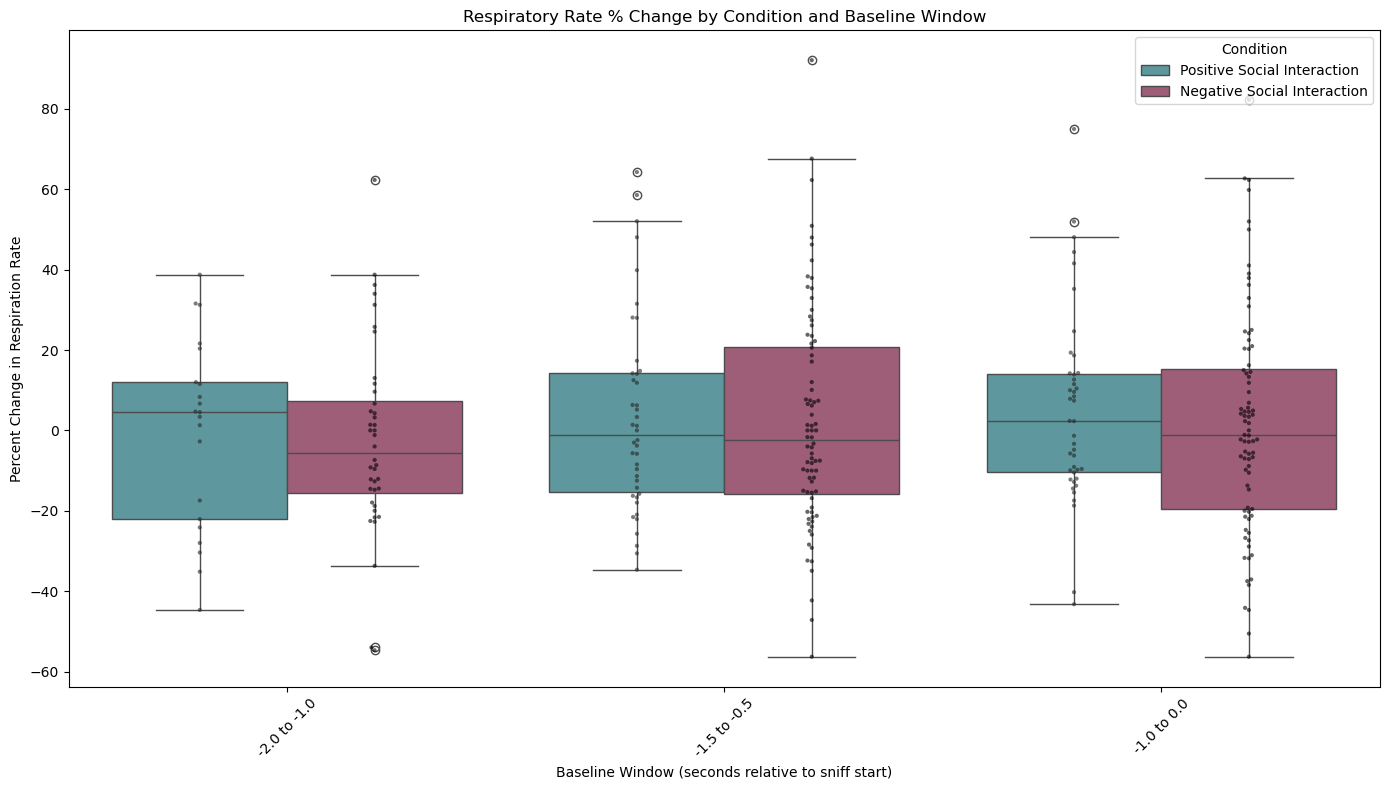

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# Define your color palette with labels for legend
palette = {
    'RI1': (83/255, 161/255, 169/255),  # Positive Social Interaction color
    'RI2': (169/255, 83/255, 118/255)   # Negative Social Interaction color
}

# Plot the boxplot
box = sns.boxplot(
    data=window_compare_df,
    x='Baseline Window',
    y='% Change Rate',
    hue='Condition',
    palette=palette
)

# Plot the swarmplot without adding a new legend
sns.swarmplot(
    data=window_compare_df,
    x='Baseline Window',
    y='% Change Rate',
    hue='Condition',
    dodge=True,
    color='k',
    alpha=0.6,
    size=3,
    legend=False  # THIS PREVENTS adding a second legend
)

plt.title('Respiratory Rate % Change by Condition and Baseline Window')
plt.ylabel('Percent Change in Respiration Rate')
plt.xlabel('Baseline Window (seconds relative to sniff start)')
plt.xticks(rotation=45)

# Customize legend labels manually
handles, labels = box.get_legend_handles_labels()
new_labels = ['Positive Social Interaction', 'Negative Social Interaction']
plt.legend(handles=handles, labels=new_labels, title='Condition', loc='upper right')

plt.tight_layout()
plt.show()


In [68]:
from scipy.stats import ttest_ind

behaviors = window_compare_df['Behavior'].unique()
baseline_windows = window_compare_df['Baseline Window'].unique()

for window in baseline_windows:
    print(f"\n=== Baseline window: {window} ===")
    for behavior in behaviors:
        pos_vals = window_compare_df.loc[
            (window_compare_df['Baseline Window'] == window) &
            (window_compare_df['Behavior'] == behavior) &
            (window_compare_df['Condition'] == 'RI1'), '% Change Rate'
        ].dropna()
        neg_vals = window_compare_df.loc[
            (window_compare_df['Baseline Window'] == window) &
            (window_compare_df['Behavior'] == behavior) &
            (window_compare_df['Condition'] == 'RI2'), '% Change Rate'
        ].dropna()

        if len(pos_vals) > 1 and len(neg_vals) > 1:
            stat, pval = ttest_ind(pos_vals, neg_vals, equal_var=False)
            print(f"Behavior: {behavior:20} | p-value = {pval:.4f}")
        else:
            print(f"Behavior: {behavior:20} | Not enough data")



=== Baseline window: -2.0 to -1.0 ===
Behavior: anogenital sniffing  | p-value = 0.9609
Behavior: facial sniffing      | p-value = 0.8797
Behavior: body sniffing        | p-value = 0.0926

=== Baseline window: -1.5 to -0.5 ===
Behavior: anogenital sniffing  | p-value = 0.5769
Behavior: facial sniffing      | p-value = 0.7809
Behavior: body sniffing        | p-value = 0.2326

=== Baseline window: -1.0 to 0.0 ===
Behavior: anogenital sniffing  | p-value = 0.6982
Behavior: facial sniffing      | p-value = 0.9317
Behavior: body sniffing        | p-value = 0.1071


In [69]:
# Only RI2 trials and fighting behavior
ri2_fight_df = combined_df[
    (combined_df["Condition"] == "RI2") &
    (combined_df["Behavior"].str.lower() == "fighting")  # Make sure this matches exactly
]

print(f"Found {len(ri2_fight_df)} fight events in RI2")


Found 0 fight events in RI2


In [70]:
print(combined_df.loc[combined_df["Condition"] == "RI2", "Behavior"].unique())


['facial sniffing' 'body sniffing' 'anogenital sniffing']


In [71]:
print(combined_df.columns)


Index(['Trial', 'Condition', 'Behavior', 'Sniff Time (s)', '% Change Rate',
       'Condition Label'],
      dtype='object')


In [72]:
combined_df

,Trial,Condition,Behavior,Sniff Time (s),% Change Rate,Condition Label
0,RI1_3_6,RI1,anogenital sniffing,8.862,-1.578947e+01,Positive Social Interaction
1,RI1_3_6,RI1,facial sniffing,12.069,0.000000e+00,Positive Social Interaction
2,RI1_3_6,RI1,anogenital sniffing,80.310,-8.474576e+00,Positive Social Interaction
3,RI1_3_6,RI1,facial sniffing,86.207,1.388889e+00,Positive Social Interaction
4,RI1_3_6,RI1,facial sniffing,88.034,-1.666667e+01,Positive Social Interaction
5,RI1_3_6,RI1,anogenital sniffing,90.690,-2.156863e+01,Positive Social Interaction
6,RI1_3_6,RI1,facial sniffing,107.724,-3.059361e+01,Positive Social Interaction
7,RI1_3_6,RI1,facial sniffing,183.724,-1.250000e+01,Positive Social Interaction
8,RI1_3_6,RI1,facial sniffing,200.517,4.805195e+01,Positive Social Interaction
9,RI1_3_6,RI1,facial sniffing,217.172,1.733333e+01,Positive Social Interaction


In [73]:
combined_df['Subject'] = combined_df['Trial'].apply(lambda x: '_'.join(x.split('_')[1:]))


In [74]:
unique_mice = combined_df['Subject'].unique()
print(unique_mice)

# To look at data for one subject:
mouse_id = unique_mice[0]
mouse_data = combined_df[combined_df['Subject'] == mouse_id]
print(mouse_data)


['3_6' '4_7' '2_3' '4_8' '1_1' '1_2' '2_4' '3_5']
      Trial Condition             Behavior  Sniff Time (s)  % Change Rate  \
0   RI1_3_6       RI1  anogenital sniffing           8.862  -1.578947e+01   
1   RI1_3_6       RI1      facial sniffing          12.069   0.000000e+00   
2   RI1_3_6       RI1  anogenital sniffing          80.310  -8.474576e+00   
3   RI1_3_6       RI1      facial sniffing          86.207   1.388889e+00   
4   RI1_3_6       RI1      facial sniffing          88.034  -1.666667e+01   
5   RI1_3_6       RI1  anogenital sniffing          90.690  -2.156863e+01   
6   RI1_3_6       RI1      facial sniffing         107.724  -3.059361e+01   
7   RI1_3_6       RI1      facial sniffing         183.724  -1.250000e+01   
8   RI1_3_6       RI1      facial sniffing         200.517   4.805195e+01   
9   RI1_3_6       RI1      facial sniffing         217.172   1.733333e+01   
10  RI1_3_6       RI1      facial sniffing         229.897   2.800000e+01   
11  RI1_3_6       RI1     

In [75]:
def extract_subject(trial_name):
    parts = trial_name.split('_')
    if len(parts) >= 3:
        # Combine the 2nd and 3rd parts with underscore, e.g. "3_6"
        return f"{parts[1]}_{parts[2]}"
    else:
        return None

combined_df['Subject'] = combined_df['Trial'].apply(extract_subject)
print(combined_df[['Trial', 'Subject']].drop_duplicates())


       Trial Subject
0    RI1_3_6     3_6
21   RI1_4_7     4_7
28   RI1_2_3     2_3
34   RI1_4_8     4_8
60   RI2_3_6     3_6
100  RI2_4_7     4_7
157  RI2_2_3     2_3
200  RI2_4_8     4_8
269  RI2_1_1     1_1
287  RI2_1_2     1_2
334  RI2_2_4     2_4
384  RI2_3_5     3_5


In [76]:
combined_df = combined_df.sort_values(['Subject', 'Condition'])


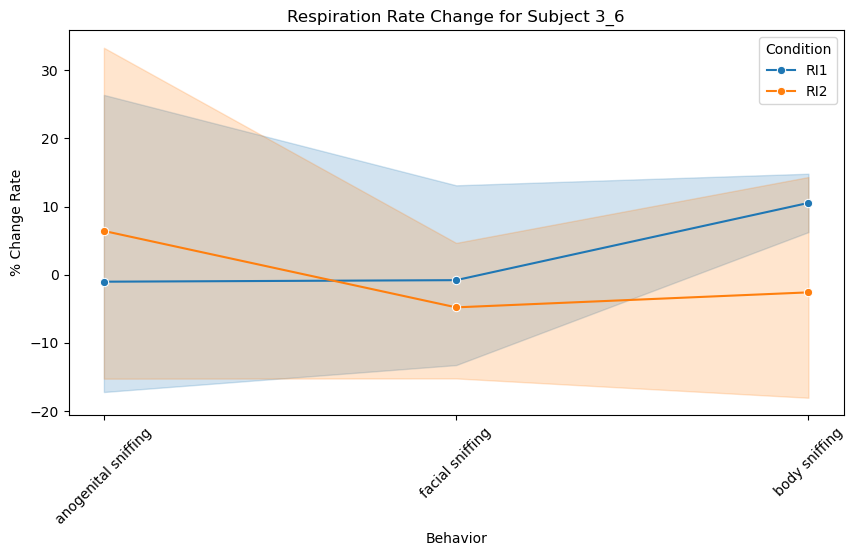

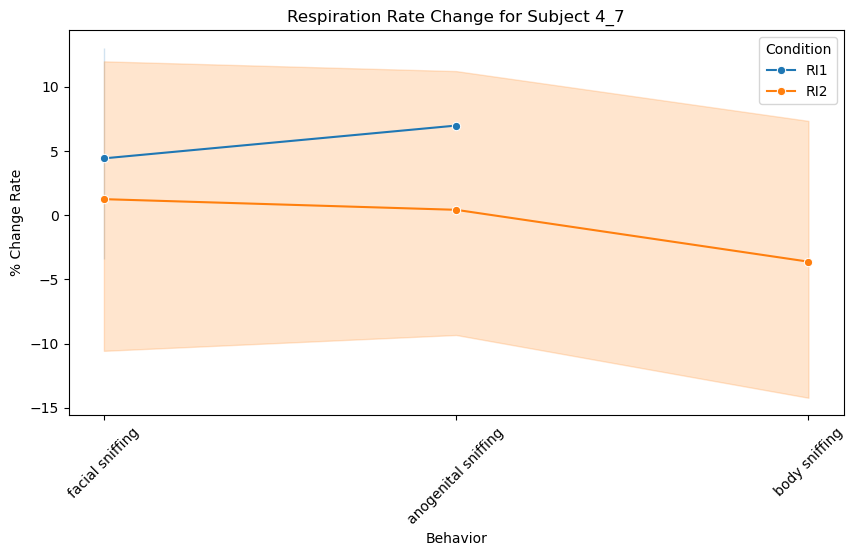

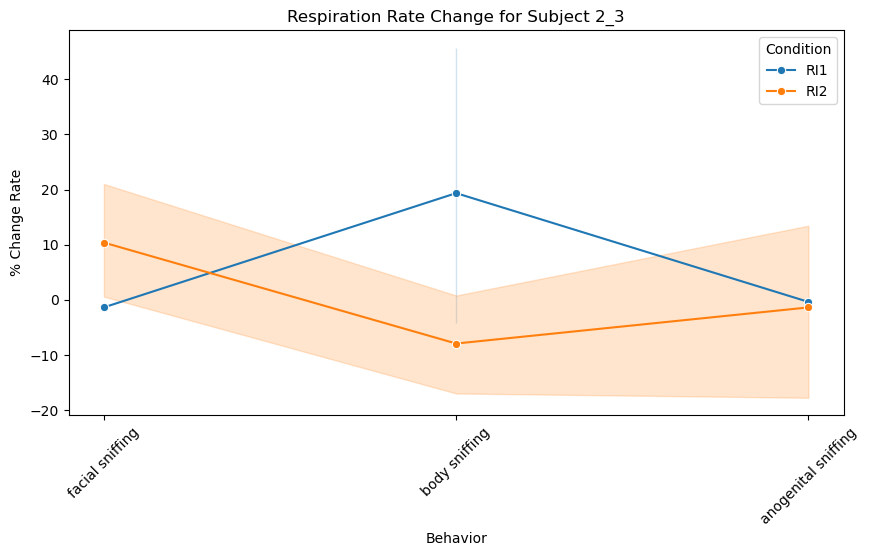

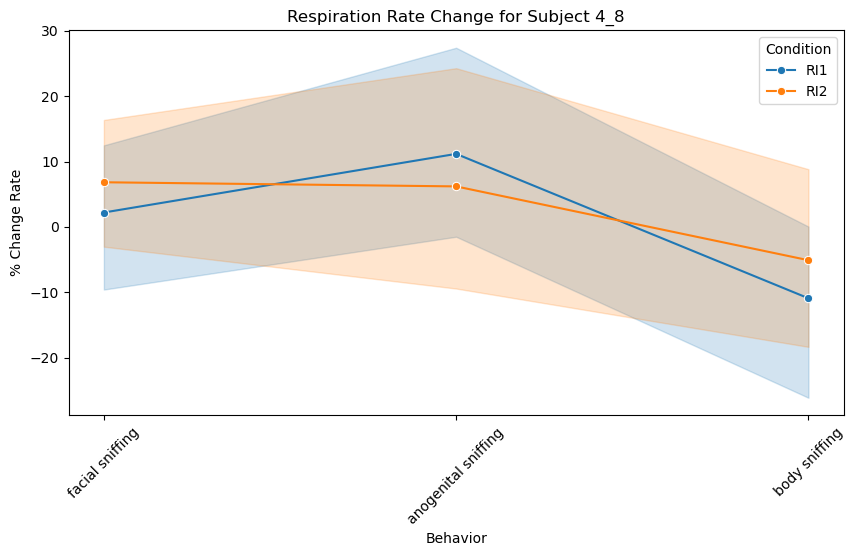

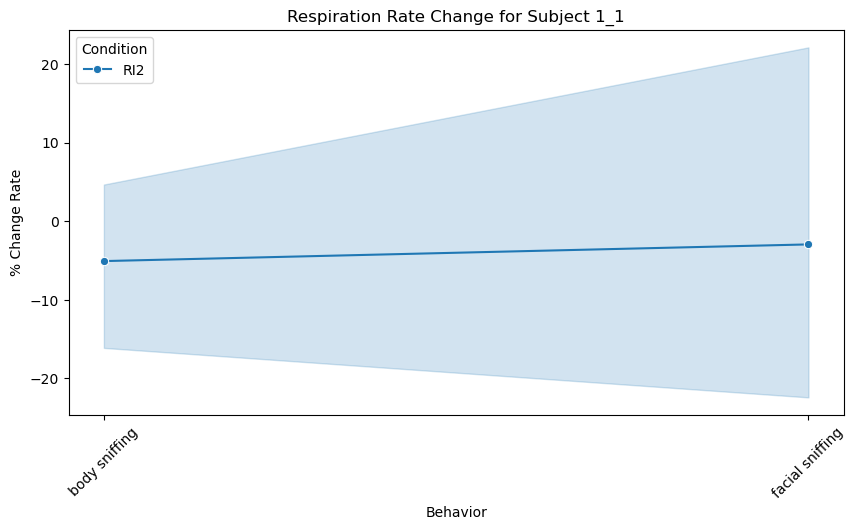

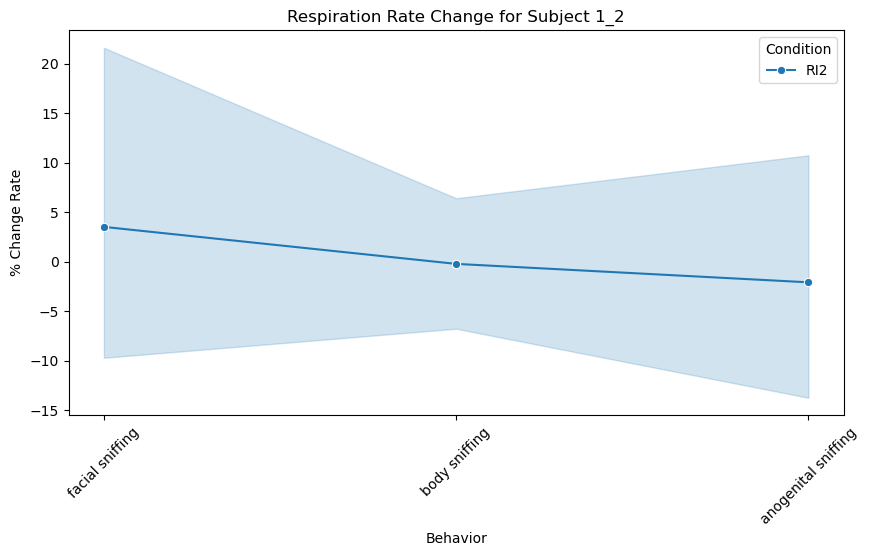

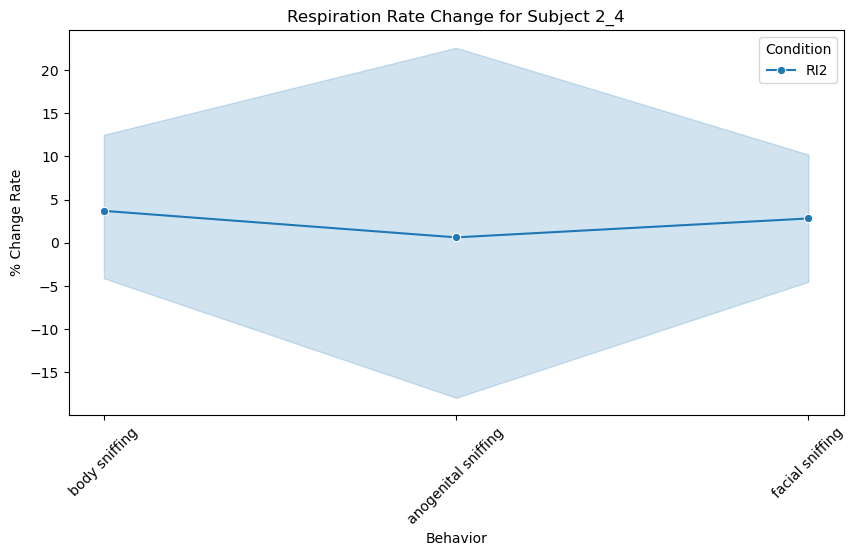

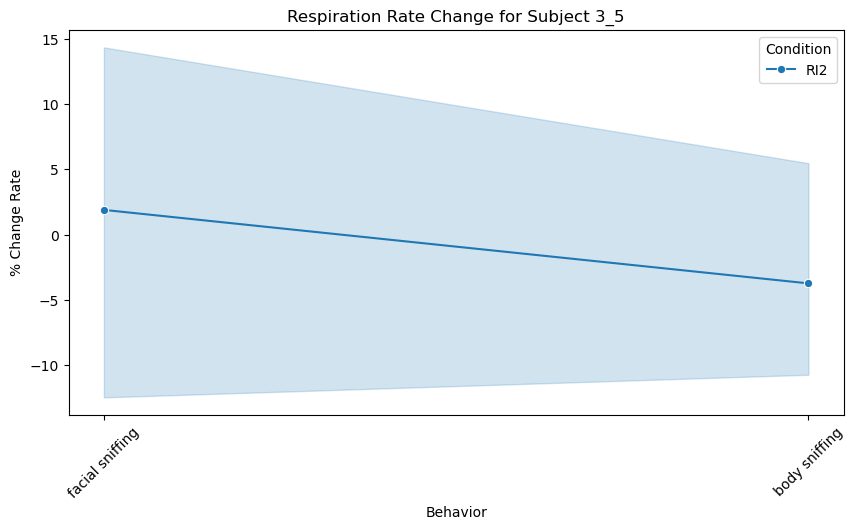

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

for mouse in unique_mice:
    mouse_data = combined_df[combined_df['Subject'] == mouse]
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=mouse_data, x='Behavior', y='% Change Rate', hue='Condition', marker='o')
    plt.title(f'Respiration Rate Change for Subject {mouse}')
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
print(combined_df['Trial'].unique())


['RI2_1_1' 'RI2_1_2' 'RI1_2_3' 'RI2_2_3' 'RI2_2_4' 'RI2_3_5' 'RI1_3_6'
 'RI2_3_6' 'RI1_4_7' 'RI2_4_7' 'RI1_4_8' 'RI2_4_8']
